In [1]:
import scanpy as sc

In [2]:
adata = sc.read_h5ad("/data7/mark/STG/dataset/snRNA/merge_SCH_new/SUS_4v4_500_1000gene/PFC_downsampled.h5ad")

In [3]:
adata.obs["celltype.L2"].value_counts()

celltype.L2
PFC L2/3 IT Glut           44466
PFC L4/5 IT Glut           25994
PFC L6 CT Glut             16253
PFC L5 IT Glut              9285
PFC L5 ET Glut              8251
PFC L6 IT Glut              8122
Astrocyte-2                 7088
PFC Pvalb GABA              6886
PFC Sst GABA                5079
PFC Lamp5 GABA              3687
OPC                         3629
PFC Vip GABA                2980
PFC L5 NP Glut              2748
MOL-1                       2531
MOL-2                       1374
Microglia-1                  985
PFC L6b Glut                 963
Astrocyte-3                  612
MFOL                         580
PFC Sncg GABA                578
Astrocyte-4                  505
COP                          480
PFC Car3 Glut                442
PFC Pvalb Vipr2 GABA         330
Arachnoid Barrier cell       278
Microglia-2                  235
MOL-3                        193
PFC Sst Chodl GABA           173
Astrocyte-1                  170
VLMC                         15

In [4]:
#adata_subset = adata[adata.obs["celltype.L2"].isin(["TH Tll1_Thsd7b Glut"])]
# 选择第二最多的细胞
adata_subset = adata[adata.obs["celltype.L2"].isin(adata.obs["celltype.L2"].value_counts().head(2).index[1:2])]
# z只选male
adata_subset = adata_subset[adata_subset.obs["sex"] == "M"]
#去掉名字包含MW22B的样本
#adata_subset = adata_subset[~adata_subset.obs["sample"].str.contains("MW22B")]

In [5]:
# 探索 subset 数据结构
print(f"adata_subset shape: {adata_subset.shape}")
print(f"Obs columns: {list(adata_subset.obs.columns)}")
print(f"X type: {type(adata_subset.X)}")
print(f"X min/max: {adata_subset.X.min():.4f} / {adata_subset.X.max():.4f}")
print(f"细胞数量: {adata_subset.n_obs}")
print(f"基因数量: {adata_subset.n_vars}")
print()
# 查看分组信息
print("celltype.L2 value counts:")
print(adata_subset.obs["celltype.L2"].value_counts())
print()
# 查看是否有 batch 信息
for col in adata_subset.obs.columns:
    if "batch" in col.lower():
        print(f"Batch column: {col}")
        print(adata_subset.obs[col].value_counts())

adata_subset shape: (11353, 16428)
Obs columns: ['sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'scrublet_score', 'predicted_doublets', 'scrublet_leiden', 'cluster_scrublet_score', 'doublet_pval', 'doublet_bh_pval', 'date', 'status', 'sex', 'donor', 'region', 'company', 'cells_number', 'fraction_reads', 'mean_reads', 'median_umi', 'median_genes', 'total_genes', 'mapped_genome', 'mapped_confidently_genome', 'mapped_intergenic', 'mapped_intronic', 'mapped_exonic', 'mapped_transcriptome', 'antisense_gene', 'reads_number', 'valid_barcodes', 'sequencing_saturation', 'q30_barcode', 'q30_rna', 'q30_umi', 'tech', 'batch', 'predicted_labels

In [6]:
# 查看可用于分组的列
for col in ["status", "region", "sex", "donor", "date"]:
    if col in adata_subset.obs.columns:
        print(f"\n{col} value counts:")
        print(adata_subset.obs[col].value_counts().head(20))


status value counts:
status
CON    5799
SUS    5554
Name: count, dtype: int64

region value counts:
region
PFC    11353
Name: count, dtype: int64

sex value counts:
sex
M    11353
Name: count, dtype: int64

donor value counts:
donor
MW26E    2000
MC25B    1754
MC21D    1598
MW34C    1562
MC33A    1290
MW26B    1190
MW51A    1047
MC52E     912
Name: count, dtype: int64

date value counts:
date
20241029    3754
20241211    3160
20241203    2480
20250102    1959
Name: count, dtype: int64


In [7]:
# 检查 adata 是否有 raw 或 layers
print("Has raw:", adata.raw is not None)
if hasattr(adata, 'layers'):
    print("Layers keys:", list(adata.layers.keys()))
print("adata_subset.X shape:", adata_subset.X.shape)
print("adata_subset.X type:", type(adata_subset.X))

# 检查 var 是否有基因名
print("\nvar columns:", list(adata_subset.var.columns[:20]))
print("var index head:", adata_subset.var.index[:5].tolist())

Has raw: False
Layers keys: ['counts', None]
adata_subset.X shape: (11353, 16428)
adata_subset.X type: <class 'anndata._core.views.SparseCSRMatrixView'>

var columns: ['gene_ids']
var index head: ['Xkr4', 'Gm1992', 'Gm19938', 'Rp1', 'Mrpl15']


In [8]:
import sys
sys.path.insert(0, "/home/junyichen/code/RUVAEDEG")
from model import RUVVAE_DEG, ZINBLoss, compute_deg, compute_deg_all_methods_legacy

import torch
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns

# 设置
batch_key = "company"
group_key = "status"
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)

# DEG 检验模式："wald"（默认，最接近 DESeq2 Wald 思路）、
# "welch"、"permutation"、"bayes" 或 "all"。
DEG_METHOD = "welch"


In [9]:
hkg_priority = [
    "Aars", "Sars",
    "Polr2a", "Polr2f",
    "Psmd6", "Psmd7", "Psma5",
    "Rer1", "Ipo8", "Pop4", "Pes1",
    "Oaz1",
    "Rpl13a", "Rpl27", "Rps13", "Rps20",
    "Hprt1", "Gusb", "Ppia", "Ywhaz"
]

candidate_negative_control_genes = [
    # 在大规模跨组织分析中相对稳定
    "Oaz1",
    "Rps13",
    "Rps20",
    "Rpl27",

    # 小鼠脑中报告相对稳定的基础基因
    "Aars",
    "Polr2f",
    "Psmd6",
    "Psmd7",
    "Psma5",

    # RNA加工、核质运输与基础细胞维护
    "Ipo8",
    "Pop4",
    "Pes1",
    "Rer1",

    # 可作为补充候选，但必须在本数据中验证
    "Rpl13a",
    "Cyc1",
    "Sdha",
    "Ubc"
]

hkg_priority = candidate_negative_control_genes 

In [10]:
# ========== 1. 准备数据（全部基因）[ZINB 模式：使用 raw counts 作为输入] ==========
adata_hvg = adata_subset.copy()

# 清理数据中的 inf/nan
X_data = adata_hvg.X.toarray() if hasattr(adata_hvg.X, 'toarray') else adata_hvg.X.copy()
X_data = np.nan_to_num(X_data, nan=0.0, posinf=0.0, neginf=0.0)
adata_hvg.X = X_data

# Normalizing to median total counts
sc.pp.normalize_total(adata_hvg)
# Logarithmize the data (用于 logFC 等 DEG 分析)
sc.pp.log1p(adata_hvg)

# 使用全部基因（不做 HVG 筛选）
n_genes_total = adata_hvg.n_vars
Y_all = X_data  # (n_cells, n_genes)
gene_names = adata_hvg.var.index.tolist()
print(f"基因总数: {n_genes_total}")
print(f"表达矩阵形状: {Y_all.shape}")
print(f"表达矩阵范围: {Y_all.min():.4f} ~ {Y_all.max():.4f}")

# 分组标签
group_labels = adata_hvg.obs[group_key].values
groups_unique = sorted(np.unique(group_labels).tolist())
print(f"分组: {groups_unique}")
print(f"CON: {(group_labels==groups_unique[0]).sum()}, CSDS: {(group_labels==groups_unique[1]).sum()}")

# 批次标签
batch_labels = adata_hvg.obs[batch_key].values
batches_unique = sorted(np.unique(batch_labels).tolist())
print(f"批次数量: {len(batches_unique)}")
print(f"批次: {batches_unique}")


基因总数: 16428
表达矩阵形状: (11353, 16428)
表达矩阵范围: 0.0000 ~ 7.9995
分组: ['CON', 'SUS']
CON: 5799, CSDS: 5554
批次数量: 3
批次: ['beirui', 'novogene', 'yunzhun']


In [11]:
# ========== 1b. 计算 n_genes_on（每个细胞检测到的基因数，用作连续协变量） ==========
# 从 raw counts 计算每个细胞表达值 > 0 的基因数。
x_raw = adata_hvg.layers["counts"].toarray() if hasattr(adata_hvg.layers["counts"], "toarray") else adata_hvg.layers["counts"]
x_raw = np.nan_to_num(x_raw, nan=0.0, posinf=0.0, neginf=0.0)
n_genes_on_raw = (x_raw > 0).sum(axis=1).astype(np.float32)

# 连续协变量必须标准化，否则会因量纲过大导致 W_cov 不稳定。
n_genes_on_mean = float(n_genes_on_raw.mean())
n_genes_on_std = float(n_genes_on_raw.std())
if n_genes_on_std < 1e-8:
    raise ValueError("n_genes_on 没有足够变异，无法作为连续协变量")
n_genes_on = ((n_genes_on_raw - n_genes_on_mean) / n_genes_on_std).astype(np.float32)
adata_hvg.obs["n_genes_on"] = n_genes_on
print(f"n_genes_on source: raw counts > 0")
print(f"raw mean/std: {n_genes_on_mean:.1f} / {n_genes_on_std:.1f}")
print(f"standardized range: {n_genes_on.min():.3f} ~ {n_genes_on.max():.3f}")


n_genes_on source: raw counts > 0
raw mean/std: 2582.1 / 794.2
standardized range: -2.001 ~ 4.189


In [12]:
# ========== 2. 选择负对照基因（HKG 文献池 + 数据驱动） ==========

# ---------- 用户选项：NC 选择策略 ----------
NC_MODE = "data_only"  # 选项: "data_only", "hkg_only", "hybrid"

# ---------- 2a. 定义 HKG 候选函数（适配小鼠基因名） ----------
import re

def build_candidate_nc_genes_mouse(gene_names):
    """构造候选负对照基因池（适配小鼠 gene symbol 大小写）"""
    
    # 1) 文献 curated housekeeping（Eisenberg & Levanon 2013, 转小鼠大小写）
    eisenberg_hkg = {
        "Actb", "B2m", "Gapdh", "Hmbs", "Hprt1", "Pgk1", "Ppia",
        "Rpl13a", "Rplp0", "Sdha", "Tbp", "Tfrc", "Ubc", "Vcp",
        "Ywhaz", "C1orf43", "Chmp2a", "Emc7", "Gpi", "Psmb2",
        "Psmb4", "Rab7a", "Reep5", "Snrpd3", "Vps29",
        "Cltc", "Csnk2b", "Ddx5", "Eef1a1", "Eif4a2",
        "Hnrnpk", "Nono", "Rpl32", "Rps18", "Sf3b1",
        "Srsf3", "Sumo1", "Ube2d2", "Usp22", "Xrn2",
    }
    
    # 2) 核糖体蛋白（细胞质 + 线粒体）
    rp_genes = {g for g in gene_names 
                if re.match(r'^(RP[SL]|Mrp[sl]|Rps|Rpl)[0-9]', g, re.IGNORECASE)}
    
    # 3) 翻译延伸因子
    eef_genes = {g for g in gene_names if re.match(r'^(Eef[12]|EIF)', g, re.IGNORECASE)}
    
    # 4) 蛋白酶体亚基
    psm_genes = {g for g in gene_names if re.match(r'^(Psm|PSM)[A-Da-d][0-9]', g)}
    
    # 5) 线粒体核糖体蛋白
    mrp_genes = {g for g in gene_names if re.match(r'^Mrp[sl][0-9]', g, re.IGNORECASE)}
    
    candidate = (eisenberg_hkg & set(gene_names)) | rp_genes | eef_genes | psm_genes | mrp_genes
    return np.array([g in candidate for g in gene_names])


# ---------- 2b. 计算表达矩阵 ----------
counts = adata_hvg.layers["counts"].toarray()
counts = np.nan_to_num(counts, nan=0.0, posinf=0.0, neginf=0.0)
Y_log = np.log1p(counts)

# 按 status 分组计算均值
mask_con = group_labels == groups_unique[0]
mask_csds = group_labels == groups_unique[1]
mean_con = Y_log[mask_con].mean(0)
mean_csds = Y_log[mask_csds].mean(0)
fc_abs = np.abs(mean_csds - mean_con)  # 两组间 logFC 绝对值

# ---------- 2c. 构造 HKG + 优先列表 ----------
hkg_mask = build_candidate_nc_genes_mouse(gene_names)
print(f"HKG 候选基因（文献+核糖体+蛋白酶体等）: {hkg_mask.sum()}")

# 用户自定义的优先 HKG 列表（确保它们一定在内参中）
priority_mask = np.zeros(n_genes_total, dtype=bool)
for hkg in hkg_priority:
    if hkg in gene_names:
        idx = gene_names.index(hkg)
        priority_mask[idx] = True
print(f"优先 HKG 列表命中: {priority_mask.sum()} / {len(hkg_priority)}")

# HKG 总池 = 文献候选 + 优先列表
hkg_combined_mask = hkg_mask | priority_mask

# ---------- 2d. 根据 NC_MODE 选择负对照基因 ----------
n_nc_total = 500  # 总负对照基因数

if NC_MODE == "data_only":
    # 纯数据驱动：从全部基因中挑选 logFC 最小的 n_nc_total 个
    nc_idx = np.argsort(fc_abs)[:n_nc_total]
    print(f"[模式: data_only] 从全部 {n_genes_total} 基因中按 |logFC| 排序挑 {n_nc_total} 个")

elif NC_MODE == "hkg_only":
    # 纯先验知识：只用 HKG 文献池 + 优先列表
    available_hkg_idx = np.where(hkg_combined_mask)[0]
    if len(available_hkg_idx) >= n_nc_total:
        # HKG 多于目标，按 |logFC| 排序挑最小的
        hkg_fc = fc_abs.copy()
        hkg_fc[~hkg_combined_mask] = np.inf
        nc_idx = np.argsort(hkg_fc)[:n_nc_total]
        print(f"[模式: hkg_only] 从 HKG 池（{len(available_hkg_idx)}）中挑 {n_nc_total} 个")
    else:
        # HKG 不够，全部用上
        nc_idx = available_hkg_idx
        print(f"[模式: hkg_only] HKG 仅 {len(available_hkg_idx)} 个，全部用上")

elif NC_MODE == "hybrid":
    # 混合：先验 HKG + 数据驱动补足
    n_hkg = hkg_combined_mask.sum()
    if n_hkg >= n_nc_total:
        hkg_fc = fc_abs.copy()
        hkg_fc[~hkg_combined_mask] = np.inf
        nc_idx = np.argsort(hkg_fc)[:n_nc_total]
        print(f"[模式: hybrid] HKG={n_hkg} ≥ {n_nc_total}，从 HKG 中挑 |logFC| 最小的")
    else:
        remaining = n_nc_total - n_hkg
        non_hkg_fc = fc_abs.copy()
        non_hkg_fc[hkg_combined_mask] = np.inf
        data_idx = np.argsort(non_hkg_fc)[:remaining]
        nc_idx = np.concatenate([np.where(hkg_combined_mask)[0], data_idx])
        print(f"[模式: hybrid] HKG={n_hkg} 全部保留 + 数据驱动补 {remaining} 个")
else:
    raise ValueError(f"NC_MODE = {NC_MODE} 不支持，请用 'data_only' / 'hkg_only' / 'hybrid'")

neg_control_mask = np.zeros(n_genes_total, dtype=bool)
neg_control_mask[nc_idx] = True

# ---------- 2e. 打印详细统计 ----------
nc_hkg_overlap = neg_control_mask & hkg_combined_mask
nc_priority_overlap = neg_control_mask & priority_mask
print(f"\n最终负对照基因: {neg_control_mask.sum()}")
print(f"  其中 HKG 文献候选: {nc_hkg_overlap.sum()}")
print(f"  其中优先 HKG 列表: {nc_priority_overlap.sum()}")
print(f"  其中非 HKG（仅 hybrid 模式）: {neg_control_mask.sum() - nc_hkg_overlap.sum()}")
print(f"\n负对照基因 (前10): {[gene_names[i] for i in nc_idx[:10]]}")
print(f"负对照基因 logFC 范围: {fc_abs[nc_idx].min():.4f} ~ {fc_abs[nc_idx].max():.4f}")

HKG 候选基因（文献+核糖体+蛋白酶体等）: 301
优先 HKG 列表命中: 17 / 17
[模式: data_only] 从全部 16428 基因中按 |logFC| 排序挑 500 个

最终负对照基因: 500
  其中 HKG 文献候选: 6
  其中优先 HKG 列表: 0
  其中非 HKG（仅 hybrid 模式）: 494

负对照基因 (前10): ['Hsd17b7', 'Zfp472', 'Pld4', 'Srxn1', 'Tunar', 'Fkbp9', 'Prpf40a', 'Cdk19', 'Myh11', 'Usp51']
负对照基因 logFC 范围: 0.0000 ~ 0.0001


In [13]:
# ========== 3. 训练 RUVVAE_DEG [ZINB 模式 + KL annealing] ==========
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"使用设备: {device}")

# 初始化模型（use_zinb=True 启用 scVI 风格的 ZINB loss）
model = RUVVAE_DEG(
    n_genes=n_genes_total,
    n_group=2,
    n_batch=len(batches_unique),
    n_genes_on=1,
    d_bio=32,
    k_unk=5,
    use_zinb=True   # <--- ZINB loss
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)

# 准备 covariate 字典
group_idx = np.array([groups_unique.index(g) for g in group_labels])
c_dict = {"group": torch.FloatTensor(np.eye(len(groups_unique))[group_idx]).to(device)}
batch_idx = np.array([batches_unique.index(b) for b in batch_labels])
c_dict["batch"] = torch.FloatTensor(np.eye(len(batches_unique))[batch_idx]).to(device)
c_dict["n_genes_on"] = torch.FloatTensor(n_genes_on[:, None]).to(device)

# ZINB 使用 raw counts (非 log1p) 作为模型输入
Y_input = counts  # (n_cells, n_genes) raw UMI counts
Y_t = torch.FloatTensor(Y_input).to(device)
nc_mask_t = torch.BoolTensor(neg_control_mask).to(device)

n_epochs = 150
batch_size = 256
n_cells = Y_t.shape[0]

# ---- KL annealing 参数 ----
KL_WARMUP = 40         # 预热 epoch 数
KL_TARGET_Z = 1.0      # z KL 目标权重（更高 → 更强正则）
KL_TARGET_W = 0.5      # w KL 目标权重

loss_history = {"total": [], "recon": [], "kl_z": [], "kl_w": [], "nc": [], "beta_kl": []}

print(f"开始训练 {n_epochs} epochs, batch_size={batch_size}...")
print(f"输入数据: raw counts, range [{Y_input.min():.0f}, {Y_input.max():.0f}]")
print(f"KL annealing: warmup={KL_WARMUP} epochs, target β_z={KL_TARGET_Z}, β_w={KL_TARGET_W}")

for epoch in range(n_epochs):
    # ---- KL annealing schedule: linear warmup ----
    if epoch < KL_WARMUP:
        beta = (epoch + 1) / KL_WARMUP
    else:
        beta = 1.0
    beta_z = beta * KL_TARGET_Z
    beta_w = beta * KL_TARGET_W

    perm = torch.randperm(n_cells)
    epoch_losses = {"total": 0, "recon": 0, "kl_z": 0, "kl_w": 0, "nc": 0}
    n_batches = 0
    
    for i in range(0, n_cells, batch_size):
        idx = perm[i:i+batch_size]
        y_batch = Y_t[idx]
        
        batch_c_dict = {}
        for k, v in c_dict.items():
            batch_c_dict[k] = v[idx]
        
        optimizer.zero_grad()
        out = model(y_batch, batch_c_dict, nc_mask_t)
        losses = out["losses"]
        
        # 用 annealing 后的 beta 权重
        loss = (losses["recon"]
                + beta_z * losses["kl_z"]
                + beta_w * losses["kl_w"]
                + 1.0 * losses["nc_total"])
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()
        
        epoch_losses["total"] += loss.item()
        epoch_losses["recon"] += losses["recon"].item()
        epoch_losses["kl_z"] += losses["kl_z"].item()
        epoch_losses["kl_w"] += losses["kl_w"].item()
        epoch_losses["nc"] += losses["nc_total"].item()
        n_batches += 1
    
    scheduler.step(epoch_losses["total"] / n_batches)
    
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1:3d}/{n_epochs} | β={beta:.2f} | "
              f"Loss: {epoch_losses['total']/n_batches:.4f} | "
              f"Recon: {epoch_losses['recon']/n_batches:.4f} | "
              f"KL_z: {epoch_losses['kl_z']/n_batches:.4f} | "
              f"KL_w: {epoch_losses['kl_w']/n_batches:.4f} | "
              f"NC: {epoch_losses['nc']/n_batches:.4f}")
    
    for k in loss_history:
        if k in epoch_losses:
            loss_history[k].append(epoch_losses[k] / n_batches)
    loss_history["beta_kl"].append(beta_z)

print("训练完成！")

# ---- ZINB 参数快照 ----
with torch.no_grad():
    px_r_np = model.px_r.detach().cpu().numpy()
    print(f"\nZINB px_r (逆离散度 θ): mean={px_r_np.mean():.3f}, std={px_r_np.std():.3f}, "
          f"range=[{px_r_np.min():.3f}, {px_r_np.max():.3f}]")


使用设备: cuda
开始训练 150 epochs, batch_size=256...
输入数据: raw counts, range [0, 4774]
KL annealing: warmup=40 epochs, target β_z=1.0, β_w=0.5
Epoch  20/150 | β=0.50 | Loss: 0.5229 | Recon: 0.4719 | KL_z: 0.0080 | KL_w: 0.0000 | NC: 0.0470
Epoch  40/150 | β=1.00 | Loss: 0.5182 | Recon: 0.4713 | KL_z: 0.0001 | KL_w: 0.0000 | NC: 0.0468
Epoch  60/150 | β=1.00 | Loss: 0.5150 | Recon: 0.4683 | KL_z: 0.0000 | KL_w: 0.0000 | NC: 0.0466
Epoch  80/150 | β=1.00 | Loss: 0.5132 | Recon: 0.4666 | KL_z: 0.0000 | KL_w: 0.0000 | NC: 0.0466
Epoch 100/150 | β=1.00 | Loss: 0.5124 | Recon: 0.4657 | KL_z: 0.0000 | KL_w: 0.0000 | NC: 0.0466
Epoch 120/150 | β=1.00 | Loss: 0.5112 | Recon: 0.4647 | KL_z: 0.0000 | KL_w: 0.0000 | NC: 0.0466
Epoch 140/150 | β=1.00 | Loss: 0.5105 | Recon: 0.4640 | KL_z: 0.0000 | KL_w: 0.0000 | NC: 0.0465
训练完成！

ZINB px_r (逆离散度 θ): mean=4.123, std=1.154, range=[-0.935, 5.740]


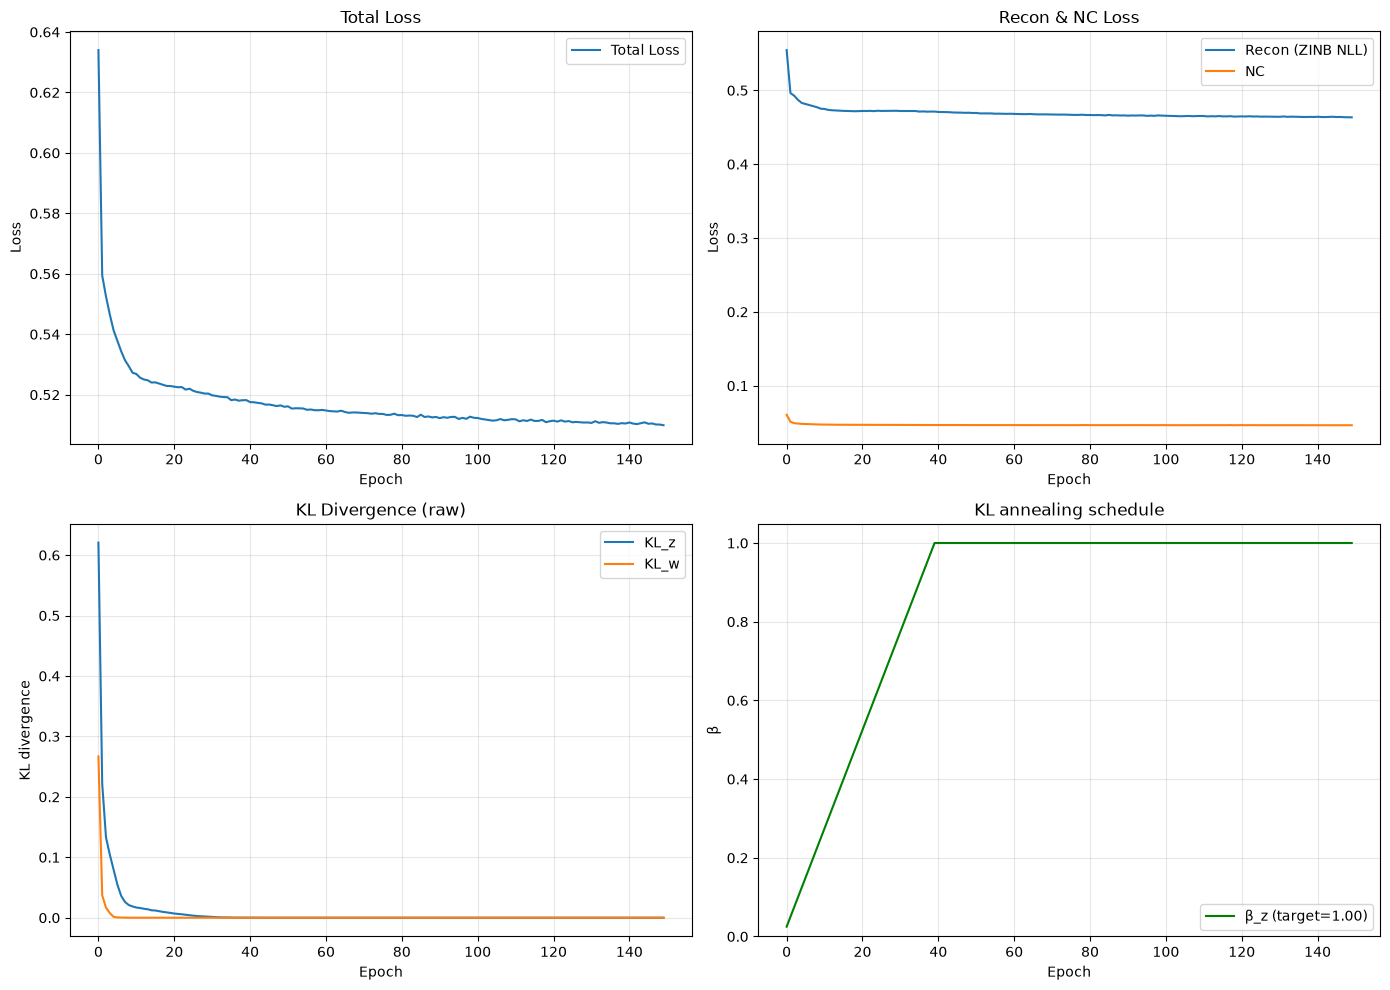

In [14]:
# ========== 4. 训练损失可视化（含 KL annealing）==========
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(loss_history["total"], label="Total Loss")
axes[0, 0].set_xlabel("Epoch"); axes[0, 0].set_ylabel("Loss"); axes[0, 0].set_title("Total Loss")
axes[0, 0].legend(); axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(loss_history["recon"], label="Recon (ZINB NLL)")
axes[0, 1].plot(loss_history["nc"], label="NC")
axes[0, 1].set_xlabel("Epoch"); axes[0, 1].set_ylabel("Loss"); axes[0, 1].set_title("Recon & NC Loss")
axes[0, 1].legend(); axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(loss_history["kl_z"], label="KL_z")
axes[1, 0].plot(loss_history["kl_w"], label="KL_w")
axes[1, 0].set_xlabel("Epoch"); axes[1, 0].set_ylabel("KL divergence"); axes[1, 0].set_title("KL Divergence (raw)")
axes[1, 0].legend(); axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(loss_history["beta_kl"], label=f"β_z (target={loss_history['beta_kl'][-1]:.2f})", color="green")
axes[1, 1].set_xlabel("Epoch"); axes[1, 1].set_ylabel("β"); axes[1, 1].set_title("KL annealing schedule")
axes[1, 1].legend(); axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_ylim(0, None)

plt.tight_layout()
plt.show()


In [15]:
# ========== 5. 按选定模式计算 DEG（在 CPU 上进行）[ZINB: 用 raw counts] ==========
import importlib
import model as model_module
importlib.reload(model_module)
from model import RUVVAE_DEG, compute_deg, compute_deg_all_methods_legacy
from scipy.stats import false_discovery_control

model_cpu = model.cpu()
deg_df, extra = compute_deg(
    model_cpu,
    counts,  # ZINB 使用 raw counts
    gene_names,
    group_labels,
    groups_unique,
    neg_control_mask,
    batch_labels=batch_labels,
    n_genes_on=n_genes_on,
    method=DEG_METHOD,
    n_posterior=200,  # 仅 bayes/all 使用
    n_perm=500,       # 仅 permutation/all 使用
)

# 统一 p-value 与 FDR
deg_df["fdr"] = false_discovery_control(deg_df["p_value"].values)
print(f"DEG method: {DEG_METHOD}")
print(f"DEG 结果: {deg_df.shape[0]} 个基因")
print(f"p<0.05: {(deg_df['p_value'] < 0.05).sum()}")
print(f"FDR<0.05: {(deg_df['fdr'] < 0.05).sum()}")
print(f"\n列名: {list(deg_df.columns)}")

# ---------- Top 20：按 |logFC_bio| 排序 ----------
top_deg = (
    deg_df.assign(abs_logFC_bio=np.abs(deg_df["logFC_bio"]))
    .sort_values("abs_logFC_bio", ascending=False)
    .head(20)
)
display(top_deg[[
    "gene", "logFC_group", "logFC_bio_latent", "logFC_bio",
    "logFC_uv_n_genes_on", "logFC_uv_cov",
    "p_value", "fdr", "deg_method",
]])

print(
    "\n检测协变量 UV 贡献 mean |logFC_uv_n_genes_on|: "
    f"{np.mean(np.abs(deg_df['logFC_uv_n_genes_on'])):.4f}"
)


DEG method: welch
DEG 结果: 16428 个基因
p<0.05: 4283
FDR<0.05: 2983

列名: ['gene', 'logFC_group', 'logFC_bio_latent', 'logFC_bio', 'logFC_uv_group', 'logFC_uv_linear', 'logFC_uv_n_genes_on', 'logFC_uv_latent', 'logFC_uv_cov', 'logFC_uv_total', 'p_value_empirical_t', 't_stat', 'p_value', 'test_stat', 'se', 'deg_method', 'fdr']


,gene,logFC_group,logFC_bio_latent,logFC_bio,logFC_uv_n_genes_on,logFC_uv_cov,p_value,fdr,deg_method
14093,Pde10a,-2.914505,-0.000926,-2.915431,0.270852,0.240145,3.798831e-88,5.778445e-86,welch
2424,Maml3,-2.672592,-0.003622,-2.676214,0.081847,0.094629,5.034502e-23,1.408974e-21,welch
7518,Mast3,-2.417844,0.000059,-2.417784,0.095178,0.049031,1.895169e-59,1.720101e-57,welch
2163,Tshz2,-2.236642,0.000208,-2.236434,0.075194,0.112518,4.940830e-238,1.887627e-235,welch
9315,Pcdh15,-2.219976,-0.000316,-2.220292,0.344415,0.463323,3.969742e-291,1.716182e-288,welch
15822,Sorcs3,-2.202099,0.002193,-2.199906,0.119476,0.130207,5.513022e-31,2.236245e-29,welch
8178,Ntm,-2.183623,-0.001277,-2.184900,0.340337,0.371607,1.000000e-300,4.440000e-298,welch
9312,Gm34544,-2.119797,-0.004343,-2.124140,0.072013,-0.198120,1.303047e-80,1.829611e-78,welch
11552,Syne3,-2.071179,0.000253,-2.070926,0.038937,-0.128708,1.000000e-300,4.440000e-298,welch
3124,Gm20752,1.896887,-0.003220,1.893667,0.113388,0.123433,1.019125e-55,8.455649e-54,welch



检测协变量 UV 贡献 mean |logFC_uv_n_genes_on|: 0.0242


In [16]:
# ========== 5e. 审计 group biological effect / UV 分解 ==========
# group 现在是生物学效应；UV 只包含 latent UV + batch covariate。
print("\n=== Group biological effect audit ===")
print(f"mean |logFC_group|: {np.mean(np.abs(deg_df['logFC_group'])):.4f}")
print(f"mean |logFC_bio_latent|: {np.mean(np.abs(deg_df['logFC_bio_latent'])):.4f}")
print(f"mean |logFC_uv_cov| (batch only): {np.mean(np.abs(deg_df['logFC_uv_cov'])):.4f}")
print("\nTop genes by explicit group effect:")
display(
    deg_df.assign(abs_group_effect=np.abs(deg_df["logFC_group"]))
    .nlargest(20, "abs_group_effect")
    [["gene", "logFC_group", "logFC_bio_latent", "logFC_bio", "logFC_uv_cov"]]
)
assert "logFC_group" in deg_df.columns
assert "logFC_uv_cov" in deg_df.columns
assert "logFC_uv_group" in deg_df.columns



=== Group biological effect audit ===
mean |logFC_group|: 0.0523
mean |logFC_bio_latent|: 0.0066
mean |logFC_uv_cov| (batch only): 0.0291

Top genes by explicit group effect:


,gene,logFC_group,logFC_bio_latent,logFC_bio,logFC_uv_cov
14093,Pde10a,-2.914505,-0.000926,-2.915431,0.240145
2424,Maml3,-2.672592,-0.003622,-2.676214,0.094629
7518,Mast3,-2.417844,0.000059,-2.417784,0.049031
2163,Tshz2,-2.236642,0.000208,-2.236434,0.112518
9315,Pcdh15,-2.219976,-0.000316,-2.220292,0.463323
15822,Sorcs3,-2.202099,0.002193,-2.199906,0.130207
8178,Ntm,-2.183623,-0.001277,-2.184900,0.371607
9312,Gm34544,-2.119797,-0.004343,-2.124140,-0.198120
11552,Syne3,-2.071179,0.000253,-2.070926,-0.128708
3124,Gm20752,1.896887,-0.003220,1.893667,0.123433


In [17]:
deg_df[np.abs(deg_df.logFC_bio)>0.1]

,gene,logFC_group,logFC_bio_latent,logFC_bio,logFC_uv_group,logFC_uv_linear,logFC_uv_n_genes_on,logFC_uv_latent,logFC_uv_cov,logFC_uv_total,p_value_empirical_t,t_stat,p_value,test_stat,se,deg_method,fdr
0,Xkr4,0.134513,0.002702,0.137215,0.0,0.379918,0.330754,-0.001052,0.379918,0.378866,2.348375e-21,68.399956,2.348375e-21,68.399956,0.002006,welch,5.845320e-20
1,Gm1992,-0.216047,0.001291,-0.214755,0.0,0.217505,0.096861,-0.000881,0.217505,0.216624,1.620205e-07,-159.405319,1.620205e-07,-159.405319,0.001347,welch,1.623962e-06
7,Rgs20,-0.599066,-0.001828,-0.600894,0.0,0.096125,0.131171,-0.000398,0.096125,0.095727,1.125607e-17,-359.914093,1.125607e-17,-359.914093,0.001670,welch,2.260571e-16
8,Atp6v1h,0.232510,-0.001830,0.230680,0.0,0.134785,0.123304,0.000196,0.134785,0.134982,2.035360e-06,181.550446,2.035360e-06,181.550446,0.001271,welch,1.861743e-05
13,Pcmtd1,0.185495,-0.001148,0.184347,0.0,0.105086,0.108694,-0.000066,0.105086,0.105020,2.627022e-13,111.491615,2.627022e-13,111.491615,0.001653,welch,4.052274e-12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16415,mt-Atp6,-0.260362,0.001064,-0.259298,0.0,-0.208726,0.045062,-0.000202,-0.208726,-0.208928,6.405063e-23,-134.480103,6.405063e-23,-134.480103,0.001928,welch,1.780412e-21
16417,mt-Nd3,-0.374591,0.000014,-0.374577,0.0,-0.175438,0.046074,-0.000058,-0.175438,-0.175496,7.493462e-68,-139.844955,7.493462e-68,-139.844955,0.002679,welch,8.489834e-66
16419,mt-Nd4,-0.815293,0.001843,-0.813450,0.0,-0.192742,0.035929,0.000254,-0.192742,-0.192487,1.343038e-69,-323.710815,1.343038e-69,-323.710815,0.002513,welch,1.564783e-67
16421,mt-Cytb,-0.857994,0.000372,-0.857623,0.0,-0.221182,0.034167,-0.000017,-0.221182,-0.221199,4.878370e-39,-410.404846,4.878370e-39,-410.404846,0.002090,welch,2.671395e-37


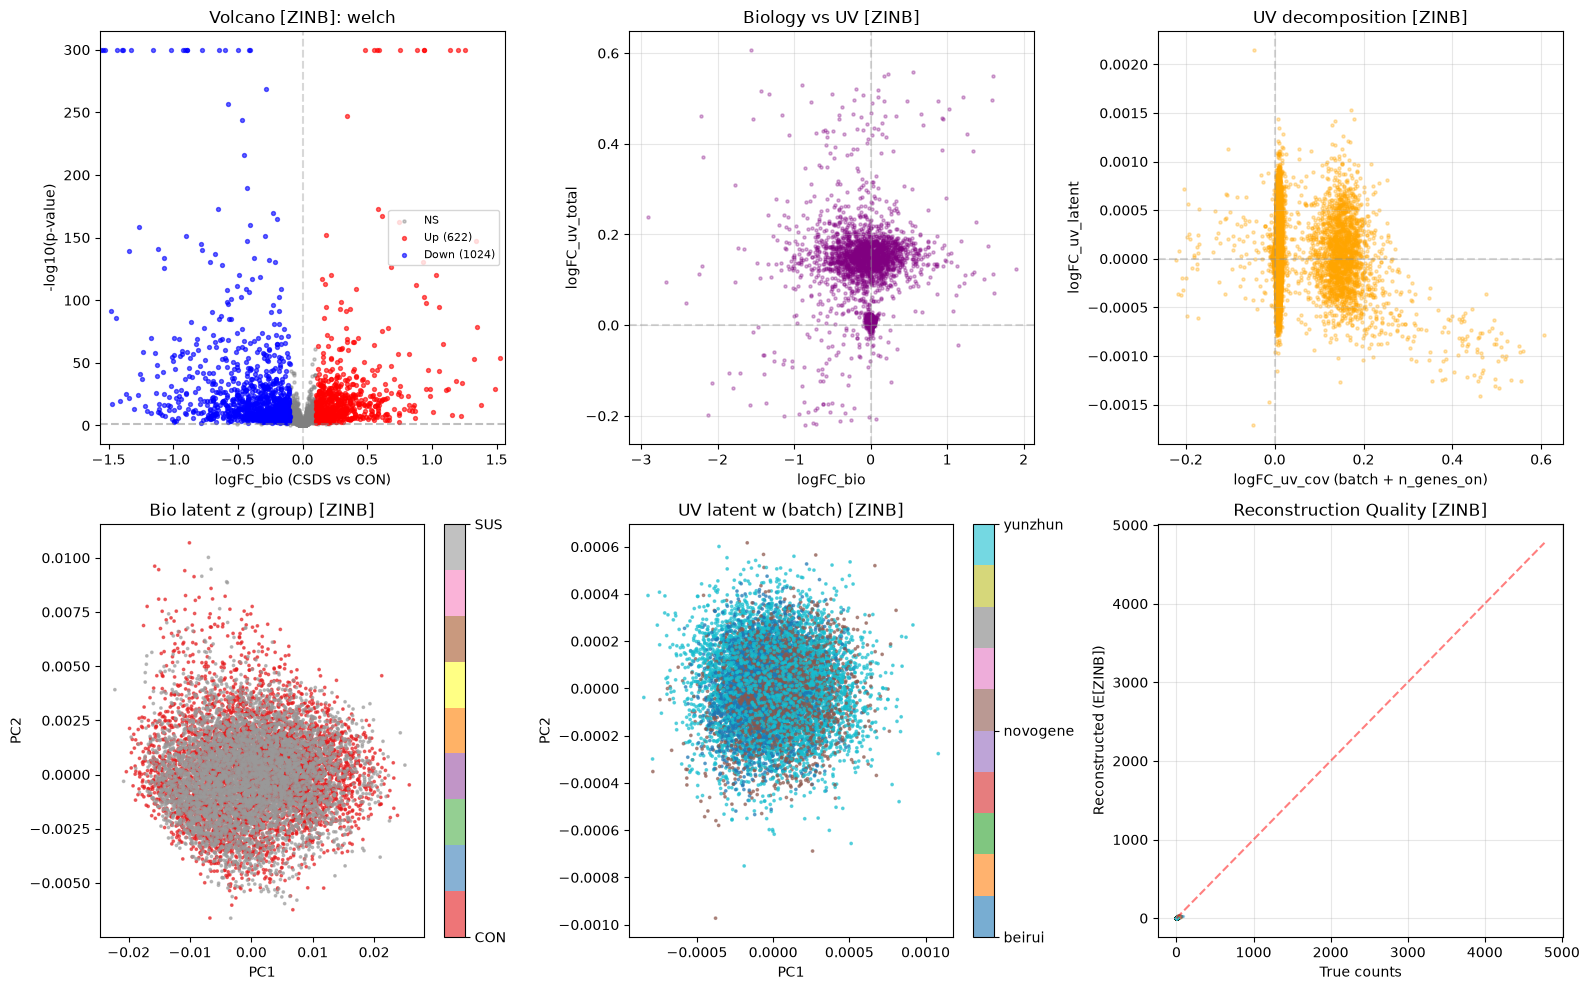

In [18]:
# ========== 6. 结果可视化：使用当前选定的 DEG 方法 [ZINB] ==========
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 6a. Volcano plot
ax = axes[0, 0]
logFC = deg_df["logFC_bio"].values
pval = deg_df["p_value"].values
neg_log_p = -np.log10(pval + 1e-300)
sig_up = (deg_df["fdr"].values < 0.05) & (logFC > 0.1)
sig_down = (deg_df["fdr"].values < 0.05) & (logFC < -0.1)
sig_ns = ~sig_up & ~sig_down
ax.scatter(logFC[sig_ns], neg_log_p[sig_ns], c="gray", alpha=0.4, s=5, label="NS")
ax.scatter(logFC[sig_up], neg_log_p[sig_up], c="red", alpha=0.6, s=8, label=f"Up ({sig_up.sum()})")
ax.scatter(logFC[sig_down], neg_log_p[sig_down], c="blue", alpha=0.6, s=8, label=f"Down ({sig_down.sum()})")
ax.axhline(-np.log10(0.05), c="gray", ls="--", alpha=0.5)
ax.axvline(0, c="gray", ls="--", alpha=0.3)
finite_logfc = logFC[np.isfinite(logFC)]
xmax = np.quantile(np.abs(finite_logfc), 0.99) * 2
ax.set_xlim(-xmax, xmax)
ax.set(xlabel="logFC_bio (CSDS vs CON)", ylabel="-log10(p-value)", title=f"Volcano [ZINB]: {DEG_METHOD}")
ax.legend(fontsize=8)

# 6b. Biological effect vs total UV
ax = axes[0, 1]
ax.scatter(deg_df["logFC_bio"], deg_df["logFC_uv_total"], alpha=0.3, s=5, c="purple")
ax.set_xlabel("logFC_bio"); ax.set_ylabel("logFC_uv_total")
ax.set_title("Biology vs UV [ZINB]"); ax.grid(True, alpha=0.3)
ax.axhline(0, c="gray", ls="--", alpha=0.3); ax.axvline(0, c="gray", ls="--", alpha=0.3)

# 6c. Known-covariate UV vs latent UV
ax = axes[0, 2]
ax.scatter(deg_df["logFC_uv_cov"], deg_df["logFC_uv_latent"], alpha=0.3, s=5, c="orange")
ax.set_xlabel("logFC_uv_cov (batch + n_genes_on)"); ax.set_ylabel("logFC_uv_latent")
ax.set_title("UV decomposition [ZINB]"); ax.grid(True, alpha=0.3)
ax.axhline(0, c="gray", ls="--", alpha=0.3); ax.axvline(0, c="gray", ls="--", alpha=0.3)

# 6d. Bio latent z PCA
from sklearn.decomposition import PCA
z_mu = np.nan_to_num(extra["z_mu"], nan=0.0)
z_pca = PCA(n_components=2).fit_transform(z_mu)
scatter = axes[1, 0].scatter(z_pca[:, 0], z_pca[:, 1], c=[groups_unique.index(g) for g in group_labels], cmap="Set1", s=3, alpha=0.6)
axes[1, 0].set_title("Bio latent z (group) [ZINB]"); axes[1, 0].set_xlabel("PC1"); axes[1, 0].set_ylabel("PC2")
cbar = plt.colorbar(scatter, ax=axes[1, 0], ticks=range(len(groups_unique))); cbar.set_ticklabels(groups_unique)

# 6e. UV latent w PCA
w_mu = np.nan_to_num(extra["w_mu"], nan=0.0)
w_pca = PCA(n_components=2).fit_transform(w_mu)
scatter = axes[1, 1].scatter(w_pca[:, 0], w_pca[:, 1], c=[batches_unique.index(b) for b in batch_labels], cmap="tab10", s=3, alpha=0.6)
axes[1, 1].set_title("UV latent w (batch) [ZINB]"); axes[1, 1].set_xlabel("PC1"); axes[1, 1].set_ylabel("PC2")
cbar = plt.colorbar(scatter, ax=axes[1, 1], ticks=range(len(batches_unique))); cbar.set_ticklabels(batches_unique)

# 6f. Reconstruction quality [ZINB: counts scale]
ax = axes[1, 2]
model_cpu.eval()
with torch.no_grad():
    c_dict_cpu = {
        "group": torch.FloatTensor(np.eye(len(groups_unique))[group_idx]),
        "batch": torch.FloatTensor(np.eye(len(batches_unique))[batch_idx]),
        "n_genes_on": torch.FloatTensor(n_genes_on[:, None]),
    }
    out = model_cpu(torch.FloatTensor(counts), c_dict_cpu, torch.BoolTensor(neg_control_mask))
    y_recon = out["y_recon"].numpy()
idx_plot = np.random.choice(counts.shape[0], min(200, counts.shape[0]), replace=False)
for i in idx_plot[:500]:
    ax.scatter(counts[i, :300], y_recon[i, :300], s=2, alpha=0.3)
ax.plot([0, counts.max()], [0, counts.max()], "r--", alpha=0.5)
ax.set_xlabel("True counts"); ax.set_ylabel("Reconstructed (E[ZINB])")
ax.set_title("Reconstruction Quality [ZINB]"); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [19]:
def compute_metrics(y_t, y_p):
    """向量化 R² + Pearson r（按基因 / 按样本 / 整体），无 for 循环"""
    # 整体 R²
    r2_total = float(r2_score(y_t.ravel(), y_p.ravel()))

    # 向量化按基因 Pearson r
    yt = y_t - y_t.mean(axis=0, keepdims=True)
    yp = y_p - y_p.mean(axis=0, keepdims=True)
    pearson_per_gene = (yt * yp).sum(axis=0) / \
        (np.sqrt((yt ** 2).sum(axis=0) * (yp ** 2).sum(axis=0)) + 1e-12)

    # 向量化按样本 Pearson r
    yt_c = y_t - y_t.mean(axis=1, keepdims=True)
    yp_c = y_p - y_p.mean(axis=1, keepdims=True)
    pearson_per_cell = (yt_c * yp_c).sum(axis=1) / \
        (np.sqrt((yt_c ** 2).sum(axis=1) * (yp_c ** 2).sum(axis=1)) + 1e-12)

    # 向量化按基因 R²
    ss_res_g = ((y_t - y_p) ** 2).sum(axis=0)
    ss_tot_g = ((y_t - y_t.mean(axis=0, keepdims=True)) ** 2).sum(axis=0) + 1e-12
    r2_per_gene = 1.0 - ss_res_g / ss_tot_g

    # 向量化按样本 R²
    ss_res_c = ((y_t - y_p) ** 2).sum(axis=1)
    ss_tot_c = ((y_t - y_t.mean(axis=1, keepdims=True)) ** 2).sum(axis=1) + 1e-12
    r2_per_cell = 1.0 - ss_res_c / ss_tot_c

    return {
        "r2_total": r2_total,
        "r2_per_gene_mean": float(np.mean(r2_per_gene)),
        "r2_per_gene_median": float(np.median(r2_per_gene)),
        "r2_per_cell_mean": float(np.mean(r2_per_cell)),
        "r2_per_cell_median": float(np.median(r2_per_cell)),
        "pearson_per_gene_mean": float(np.mean(pearson_per_gene)),
        "pearson_per_gene_median": float(np.median(pearson_per_gene)),
        "pearson_per_cell_mean": float(np.mean(pearson_per_cell)),
        "pearson_per_cell_median": float(np.median(pearson_per_cell)),
    }

In [20]:
# ========== 7. Reconstruction Quality Evaluation: R² + Pearson r [ZINB: counts scale] ==========
from sklearn.metrics import r2_score
import torch
import numpy as np
import matplotlib.pyplot as plt

model_cpu.eval()
with torch.no_grad():
    group_idx = np.array([groups_unique.index(g) for g in group_labels])
    batch_idx = np.array([batches_unique.index(b) for b in batch_labels])
    c_dict_eval = {
        "group": torch.FloatTensor(np.eye(len(groups_unique))[group_idx]),
        "batch": torch.FloatTensor(np.eye(len(batches_unique))[batch_idx]),
        "n_genes_on": torch.FloatTensor(n_genes_on[:, None]),
    }
    out_eval = model_cpu(torch.FloatTensor(counts), c_dict_eval, torch.BoolTensor(neg_control_mask))
    y_recon_eval = out_eval["y_recon"].numpy()
    y_bio_eval = out_eval["y_bio"].numpy()
    # ZINB 额外输出
    if "y_mu" in out_eval:
        y_mu_eval = out_eval["y_mu"].numpy()
        pi_eval = out_eval["pi"].numpy()

y_true = counts  # ZINB 比较 raw counts

print("=== Reconstruction Quality Evaluation [ZINB] ===\n")
metrics_recon = compute_metrics(y_true, y_recon_eval)
metrics_clean = compute_metrics(y_true, y_bio_eval)

print("[Overall Reconstruction y_recon = E[ZINB] = mu * (1-pi)]")
for k, v in metrics_recon.items():
    print(f"  {k:<28}: {v:.4f}")

print("\n[Biological Channel y_bio (Direct VAE output)]")
for k, v in metrics_clean.items():
    print(f"  {k:<28}: {v:.4f}")

print("\n=== Reconstruction Quality Summary ===")
print(f"{'Metric':<35} {'y_recon (E[ZINB])':>18} {'y_bio (Clean)':>18}")
print("-" * 75)
for k in metrics_recon:
    print(f"{k:<35} {metrics_recon[k]:>18.4f} {metrics_clean[k]:>18.4f}")

# ZINB 参数统计
if "y_mu" in out_eval:
    print(f"\n=== ZINB 参数 ===")
    print(f"y_mu (NB mean): [{y_mu_eval.min():.2f}, {y_mu_eval.max():.2f}]")
    print(f"pi (dropout): [{pi_eval.min():.3f}, {pi_eval.max():.3f}], mean={pi_eval.mean():.3f}")


=== Reconstruction Quality Evaluation [ZINB] ===

[Overall Reconstruction y_recon = E[ZINB] = mu * (1-pi)]
  r2_total                    : 0.3081
  r2_per_gene_mean            : -0.0684
  r2_per_gene_median          : -0.0478
  r2_per_cell_mean            : 0.4806
  r2_per_cell_median          : 0.5010
  pearson_per_gene_mean       : 0.0791
  pearson_per_gene_median     : 0.0231
  pearson_per_cell_mean       : 0.7941
  pearson_per_cell_median     : 0.7947

[Biological Channel y_bio (Direct VAE output)]
  r2_total                    : -1.4014
  r2_per_gene_mean            : -4189.6274
  r2_per_gene_median          : -1065.0508
  r2_per_cell_mean            : -5.3690
  r2_per_cell_median          : -2.7297
  pearson_per_gene_mean       : 0.0038
  pearson_per_gene_median     : 0.0010
  pearson_per_cell_mean       : 0.4874
  pearson_per_cell_median     : 0.4971

=== Reconstruction Quality Summary ===
Metric                               y_recon (E[ZINB])      y_bio (Clean)
----------------

Up-regulated top20: 20 (kept 20)
Down-regulated top20: 20 (kept 20)
Total top genes: 40
Group by: donor
X_uv_removed (E[ZINB]) range: 1.9853404e-08 -> 198.79597
X_bio range: 0.0 -> 193.21094


/tmp/ipykernel_2444641/4042943051.py:41: FutureWarning: The method set_figure_params is deprecated and will be removed in the future. Use :func:`scanpy.set_figure_params` instead
  sc.settings.set_figure_params(dpi=110)


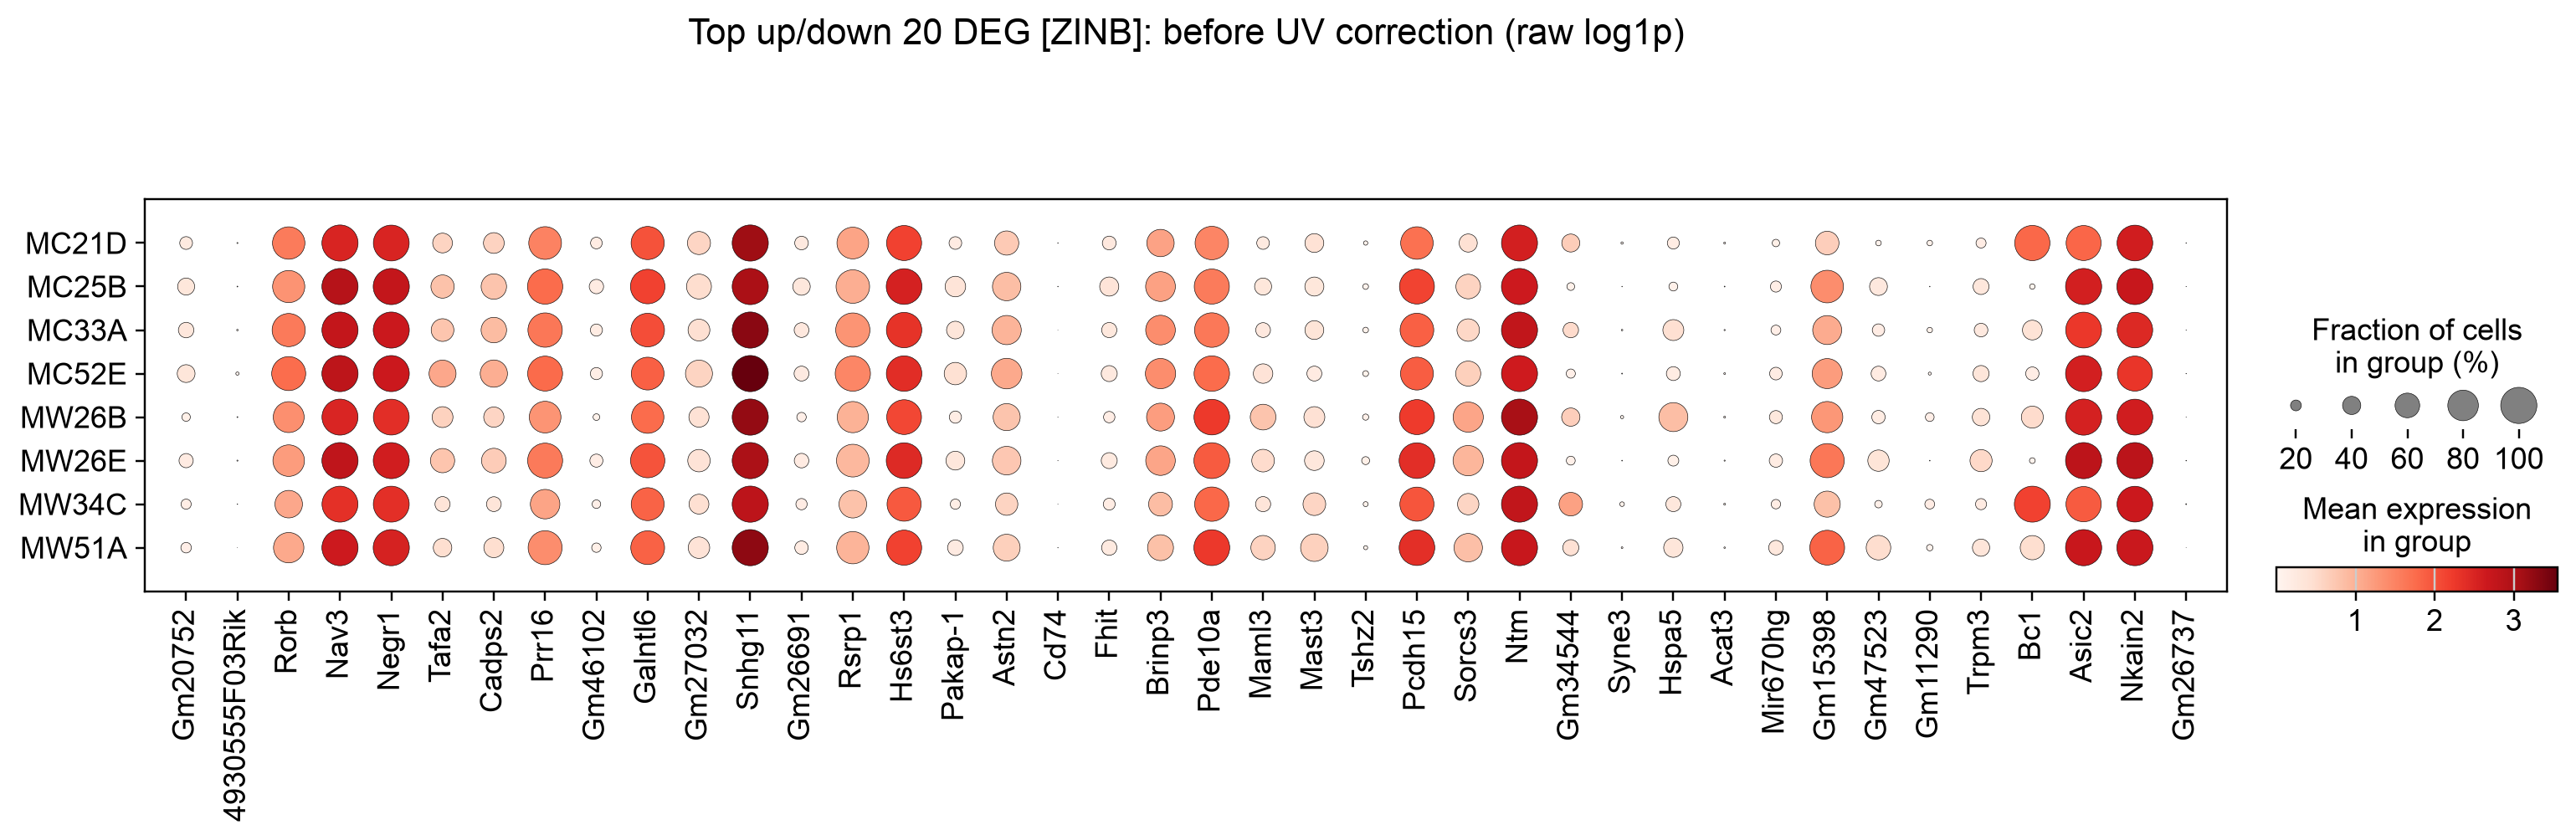

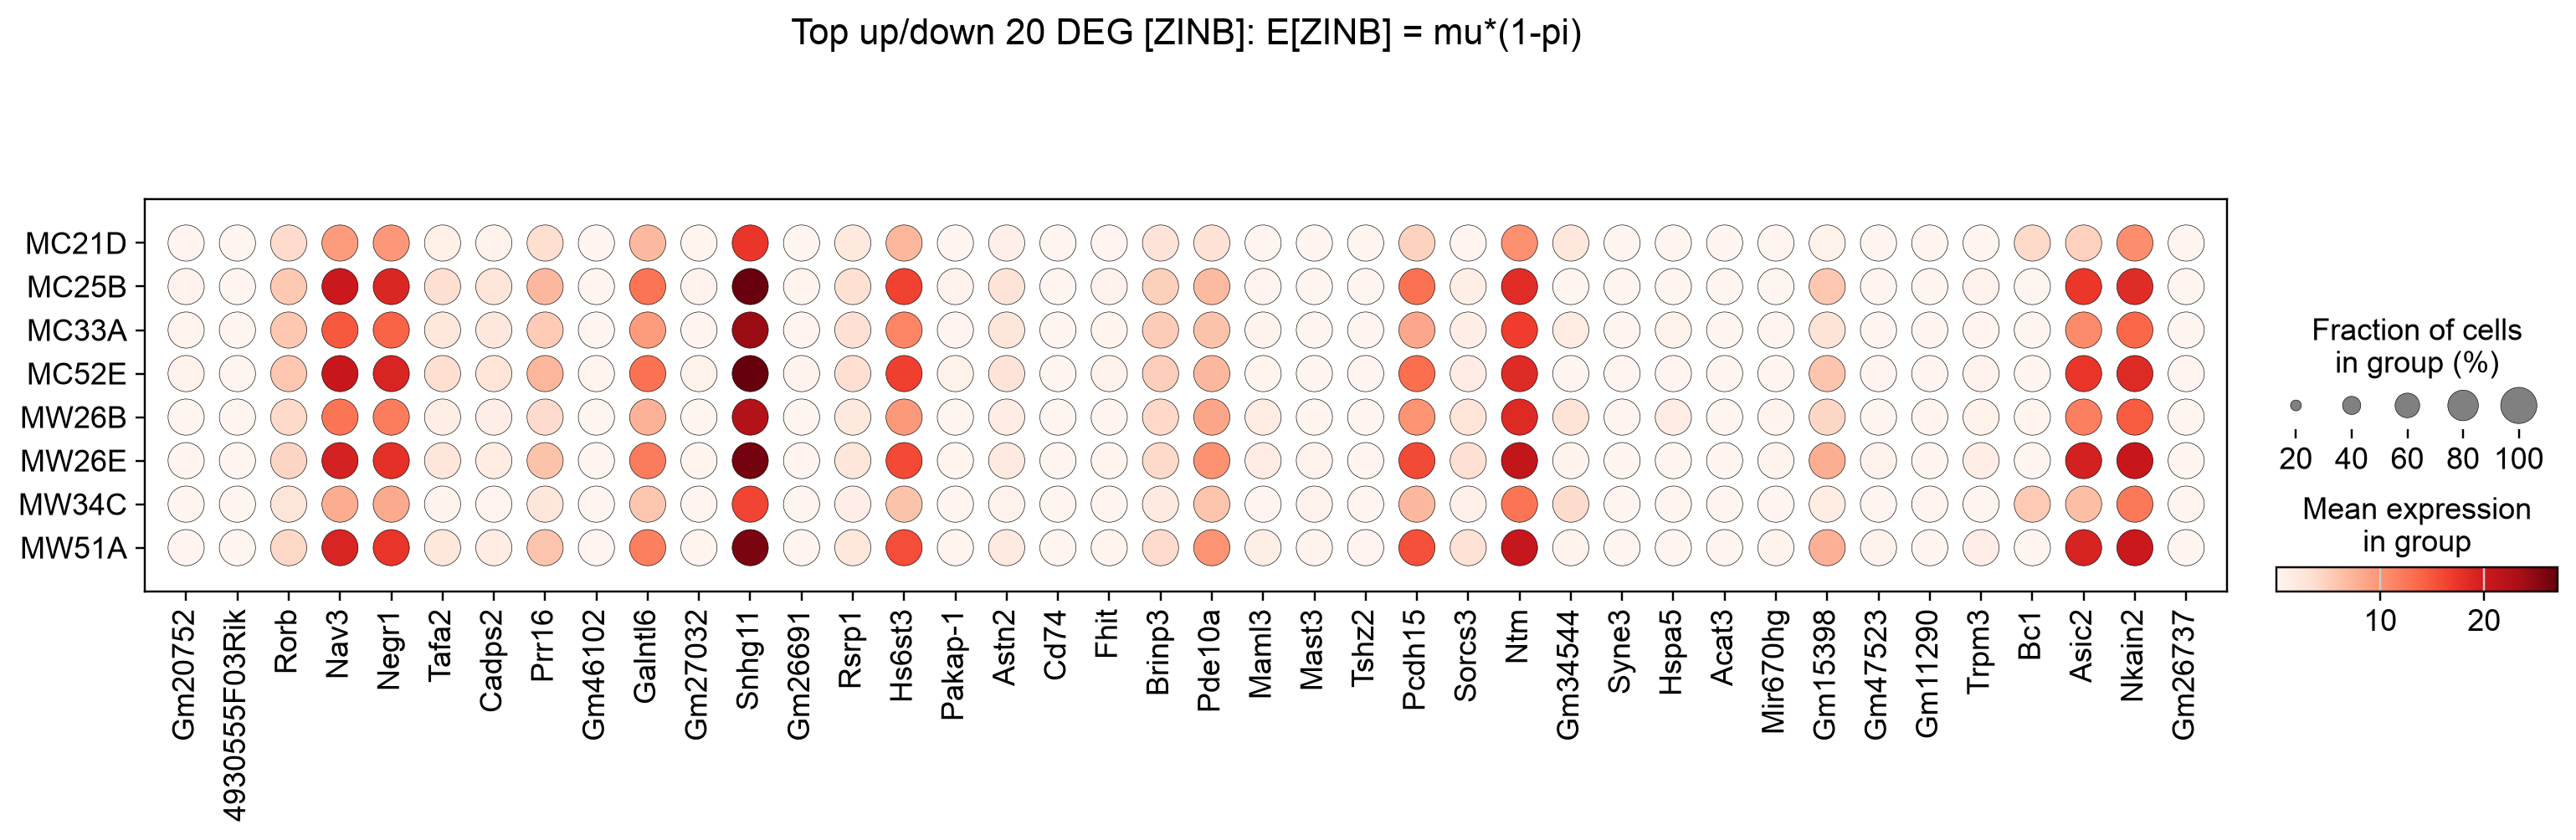

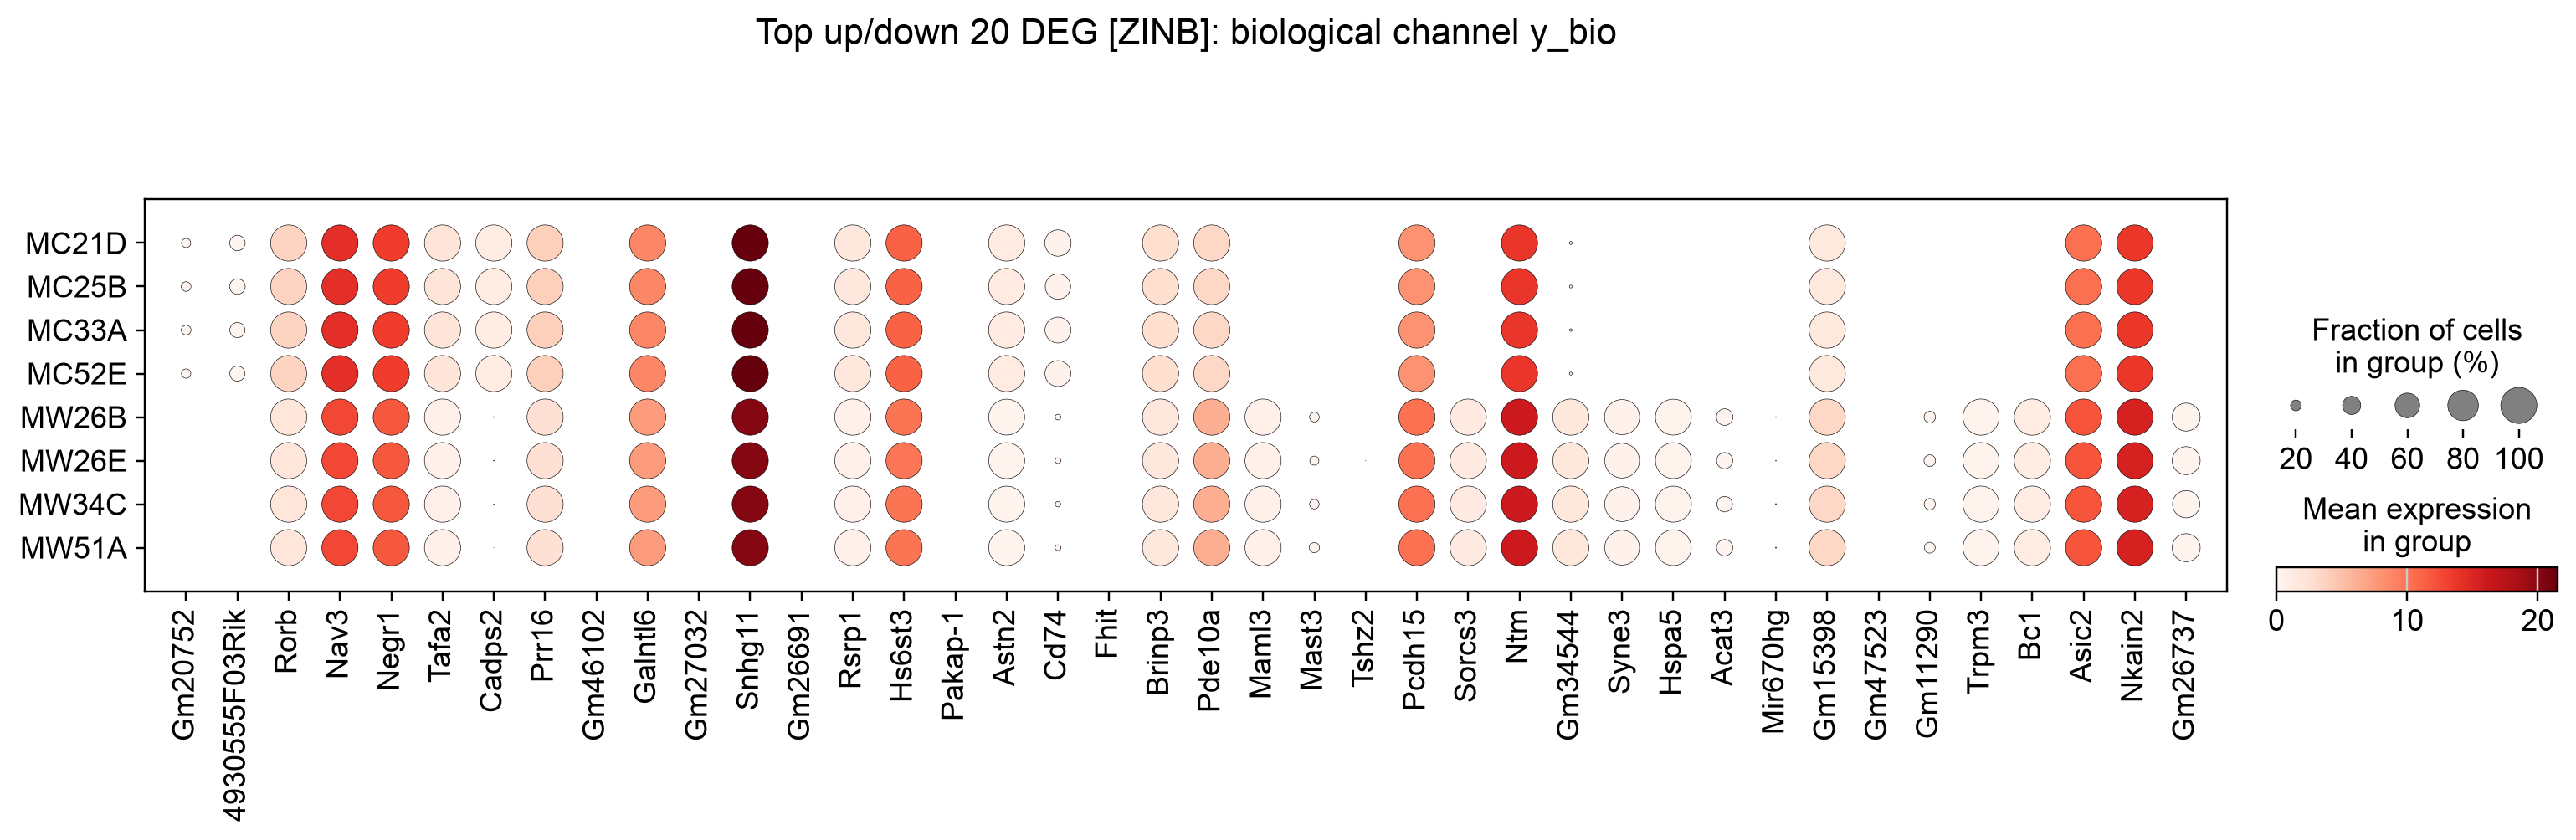

Saved: ZINB_top_updown20_before_uv.png / ZINB_top_updown20_after_uv.png / ZINB_top_updown20_bio.png


In [21]:
# ========== 9b. Scanpy dotplot：top DEG 按 sample 分组 [ZINB] ==========
groupby_key = "donor"

df_up = deg_df[deg_df["logFC_bio"] > 0].copy()
df_down = deg_df[deg_df["logFC_bio"] < 0].copy()

top_up = df_up.assign(abs_lfc=np.abs(df_up["logFC_bio"])) \
    .sort_values("abs_lfc", ascending=False).head(20)
top_down = df_down.assign(abs_lfc=np.abs(df_down["logFC_bio"])) \
    .sort_values("abs_lfc", ascending=False).head(20)

selected = pd.concat([top_up, top_down], ignore_index=True)
top_genes = [g for g in selected["gene"].tolist() if g in adata_hvg.var_names]
print(f"Up-regulated top20: {len(top_up)} (kept {len([g for g in top_up['gene'] if g in adata_hvg.var_names])})")
print(f"Down-regulated top20: {len(top_down)} (kept {len([g for g in top_down['gene'] if g in adata_hvg.var_names])})")
print(f"Total top genes: {len(top_genes)}")
print(f"Group by: {groupby_key}")

# ZINB: y_recon = mu*(1-pi) 已是预期 counts，直接使用
model_cpu.eval()
with torch.no_grad():
    c_dict_eval = {
        "group": torch.FloatTensor(np.eye(len(groups_unique))[group_idx]),
        "batch": torch.FloatTensor(np.eye(len(batches_unique))[batch_idx]),
        "n_genes_on": torch.FloatTensor(n_genes_on[:, None]),
    }
    out_eval = model_cpu(torch.FloatTensor(counts), c_dict_eval, torch.BoolTensor(neg_control_mask))
    y_recon_raw = out_eval["y_recon"].cpu().numpy()
    y_bio_raw = out_eval["y_bio"].cpu().numpy()

# ZINB 模式: y_recon 是 E[ZINB] count，clip 到 >=0
y_recon_eval = np.clip(y_recon_raw, 0.0, None)
y_bio_eval = np.clip(y_bio_raw, 0.0, None)

adata_hvg.layers["X_uv_removed"] = y_recon_eval
adata_hvg.layers["X_bio"] = y_bio_eval
print("X_uv_removed (E[ZINB]) range:", y_recon_eval.min(), "->", y_recon_eval.max())
print("X_bio range:", y_bio_eval.min(), "->", y_bio_eval.max())

# ---- 矫正前 raw log1p ----
sc.settings.set_figure_params(dpi=110)
fig = sc.pl.dotplot(
    adata_hvg,
    var_names=top_genes,
    groupby=groupby_key,
    use_raw=False,
    layer=None,
    standard_scale=None,
    cmap="Reds",
    show=False,
    title="Top up/down 20 DEG [ZINB]: before UV correction (raw log1p)",
    return_fig=True,
)
fig.savefig("ZINB_top_updown20_before_uv.png", bbox_inches="tight")

# ---- ZINB E[ZINB] 表达 ----
fig = sc.pl.dotplot(
    adata_hvg,
    var_names=top_genes,
    groupby=groupby_key,
    use_raw=False,
    layer="X_uv_removed",
    standard_scale=None,
    cmap="Reds",
    show=False,
    title="Top up/down 20 DEG [ZINB]: E[ZINB] = mu*(1-pi)",
    return_fig=True,
)
fig.savefig("ZINB_top_updown20_after_uv.png", bbox_inches="tight")

# ---- biological channel y_bio ----
fig = sc.pl.dotplot(
    adata_hvg,
    var_names=top_genes,
    groupby=groupby_key,
    use_raw=False,
    layer="X_bio",
    standard_scale=None,
    cmap="Reds",
    show=False,
    title="Top up/down 20 DEG [ZINB]: biological channel y_bio",
    return_fig=True,
)
fig.savefig("ZINB_top_updown20_bio.png", bbox_inches="tight")

plt.show()
print("Saved: ZINB_top_updown20_before_uv.png / ZINB_top_updown20_after_uv.png / ZINB_top_updown20_bio.png")


HKG 数量: 17 (['Oaz1', 'Rps13', 'Rps20', 'Rpl27', 'Aars', 'Polr2f', 'Psmd6', 'Psmd7', 'Psma5', 'Ipo8', 'Pop4', 'Pes1', 'Rer1', 'Rpl13a', 'Cyc1', 'Sdha', 'Ubc'])
Group by: donor


/tmp/ipykernel_2444641/2835771719.py:10: FutureWarning: The method set_figure_params is deprecated and will be removed in the future. Use :func:`scanpy.set_figure_params` instead
  sc.settings.set_figure_params(dpi=110)


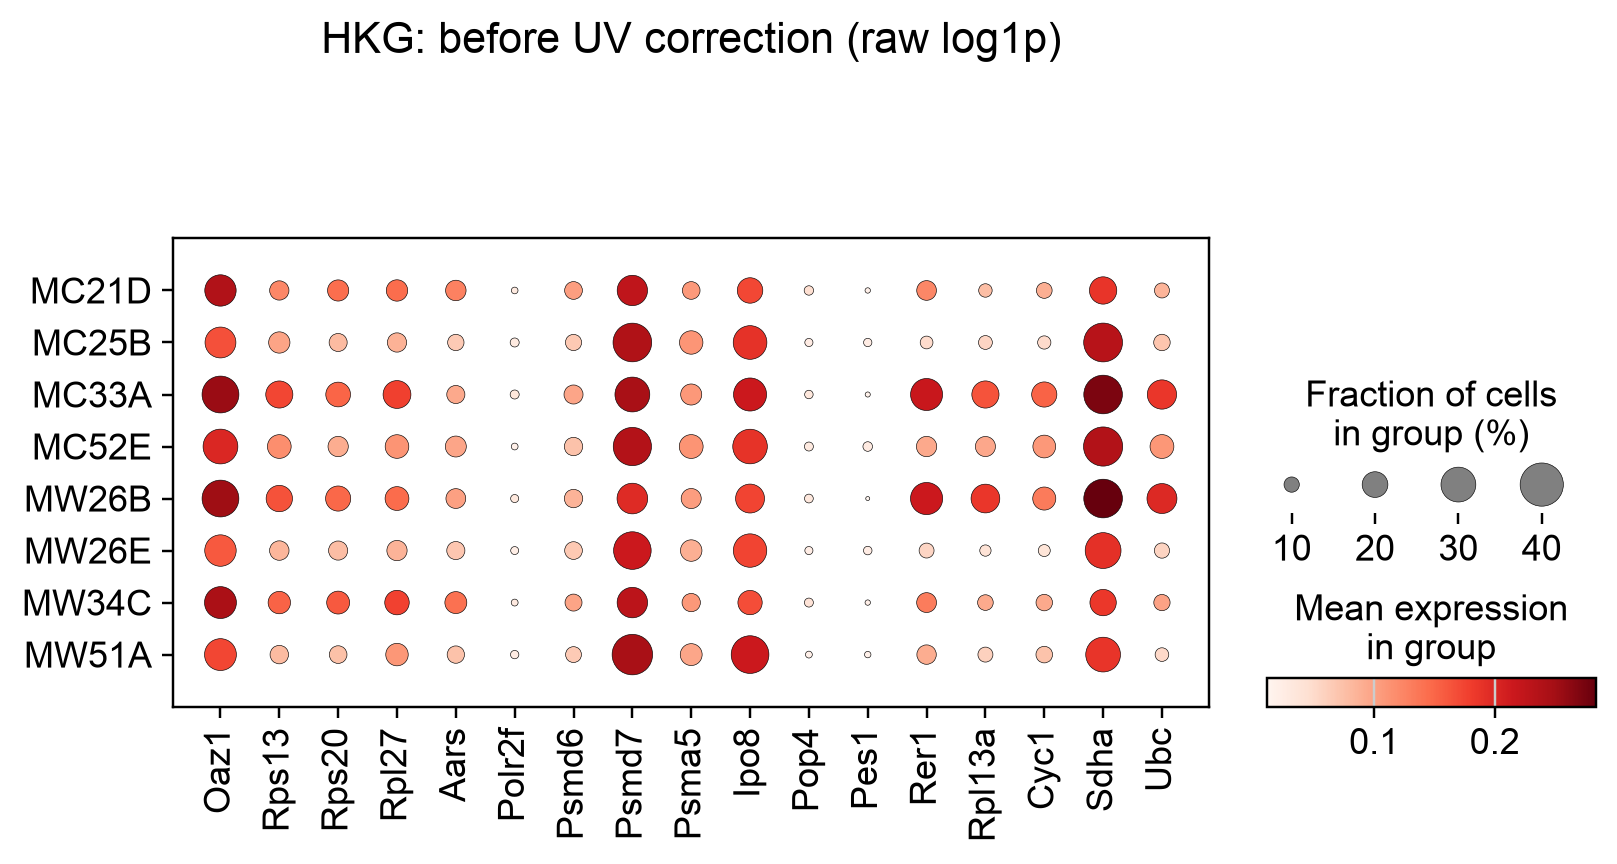

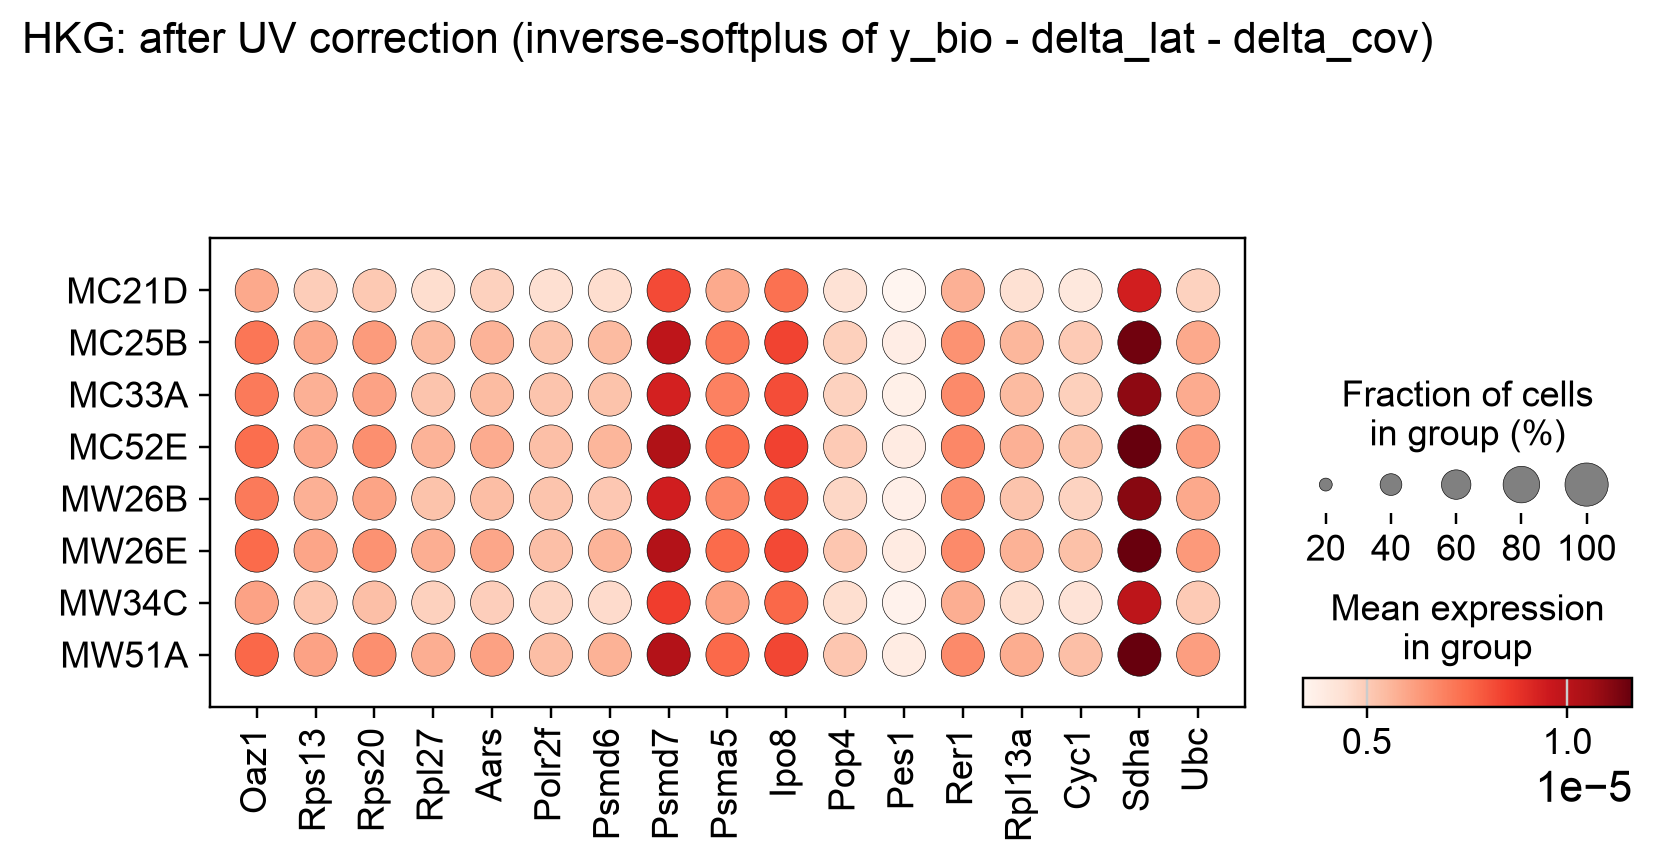

Saved: hkg_before_uv.png / hkg_after_uv.png


In [22]:
# ========== 9c. Scanpy dotplot：HKG 矫正前后按 sample 分组 ==========
groupby_key = "donor"

# 仅保留数据中存在的 HKG 基因
hkg_genes_used = [g for g in hkg_priority if g in adata_hvg.var_names]
print(f"HKG 数量: {len(hkg_genes_used)} ({hkg_genes_used})")
print(f"Group by: {groupby_key}")

# 矫正前 raw log1p
sc.settings.set_figure_params(dpi=110)
fig = sc.pl.dotplot(
    adata_hvg,
    var_names=hkg_genes_used,
    groupby=groupby_key,
    use_raw=False,
    layer=None,
    standard_scale=None,
    cmap="Reds",
    show=False,
    title="HKG: before UV correction (raw log1p)",
    return_fig=True,
)
fig.savefig("hkg_before_uv.png", bbox_inches="tight")

# 矫正后：UV-removed 表达（inverse softplus）
fig = sc.pl.dotplot(
    adata_hvg,
    var_names=hkg_genes_used,
    groupby=groupby_key,
    use_raw=False,
    layer="X_uv_removed",
    standard_scale=None,
    cmap="Reds",
    show=False,
    title="HKG: after UV correction (inverse-softplus of y_bio - delta_lat - delta_cov)",
    return_fig=True,
)
fig.savefig("hkg_after_uv.png", bbox_inches="tight")

plt.show()
print("Saved: hkg_before_uv.png / hkg_after_uv.png")

counts shape: (11353, 16428)
X_uv_removed (E[ZINB]) shape: (11353, 16428)
X_bio shape: (11353, 16428)
X_uv_part shape: (11353, 16428)


/tmp/ipykernel_2444641/415955659.py:28: FutureWarning: The method set_figure_params is deprecated and will be removed in the future. Use :func:`scanpy.set_figure_params` instead
  sc.settings.set_figure_params(dpi=110)


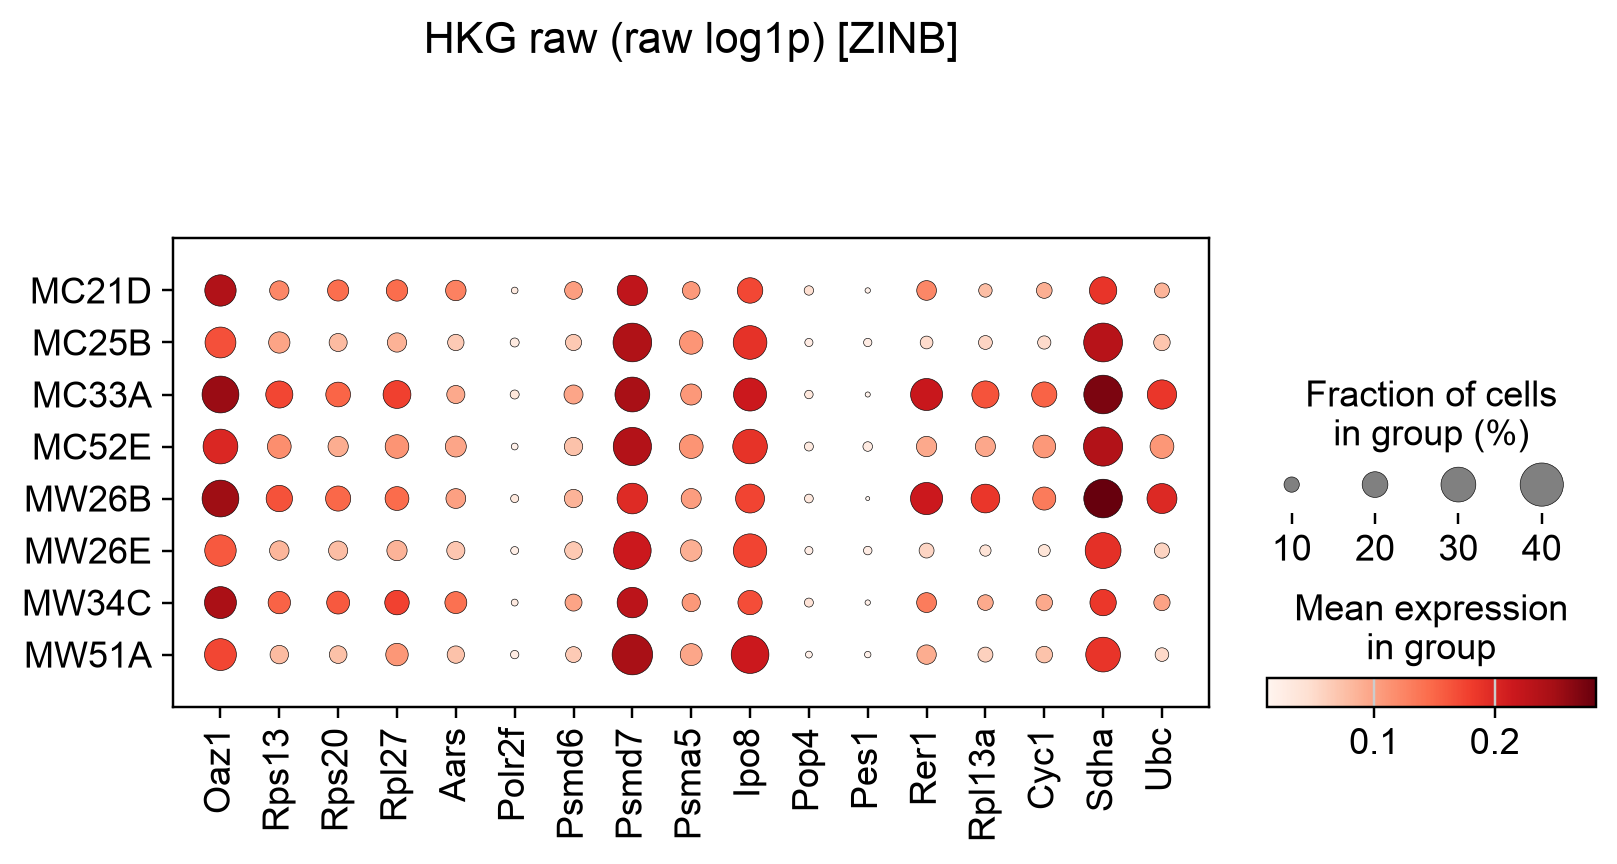

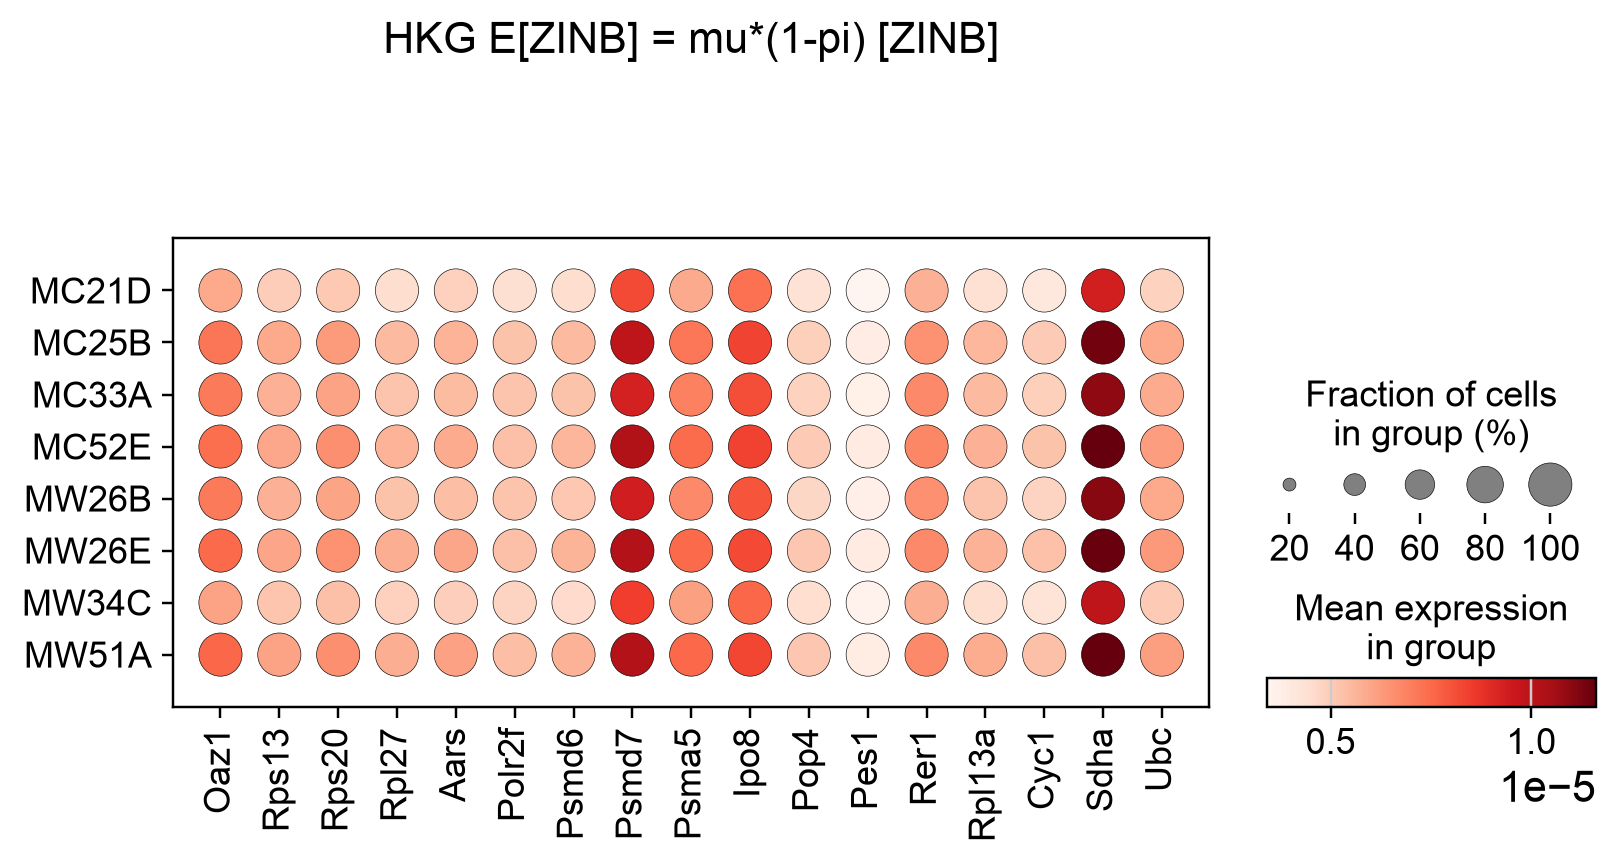

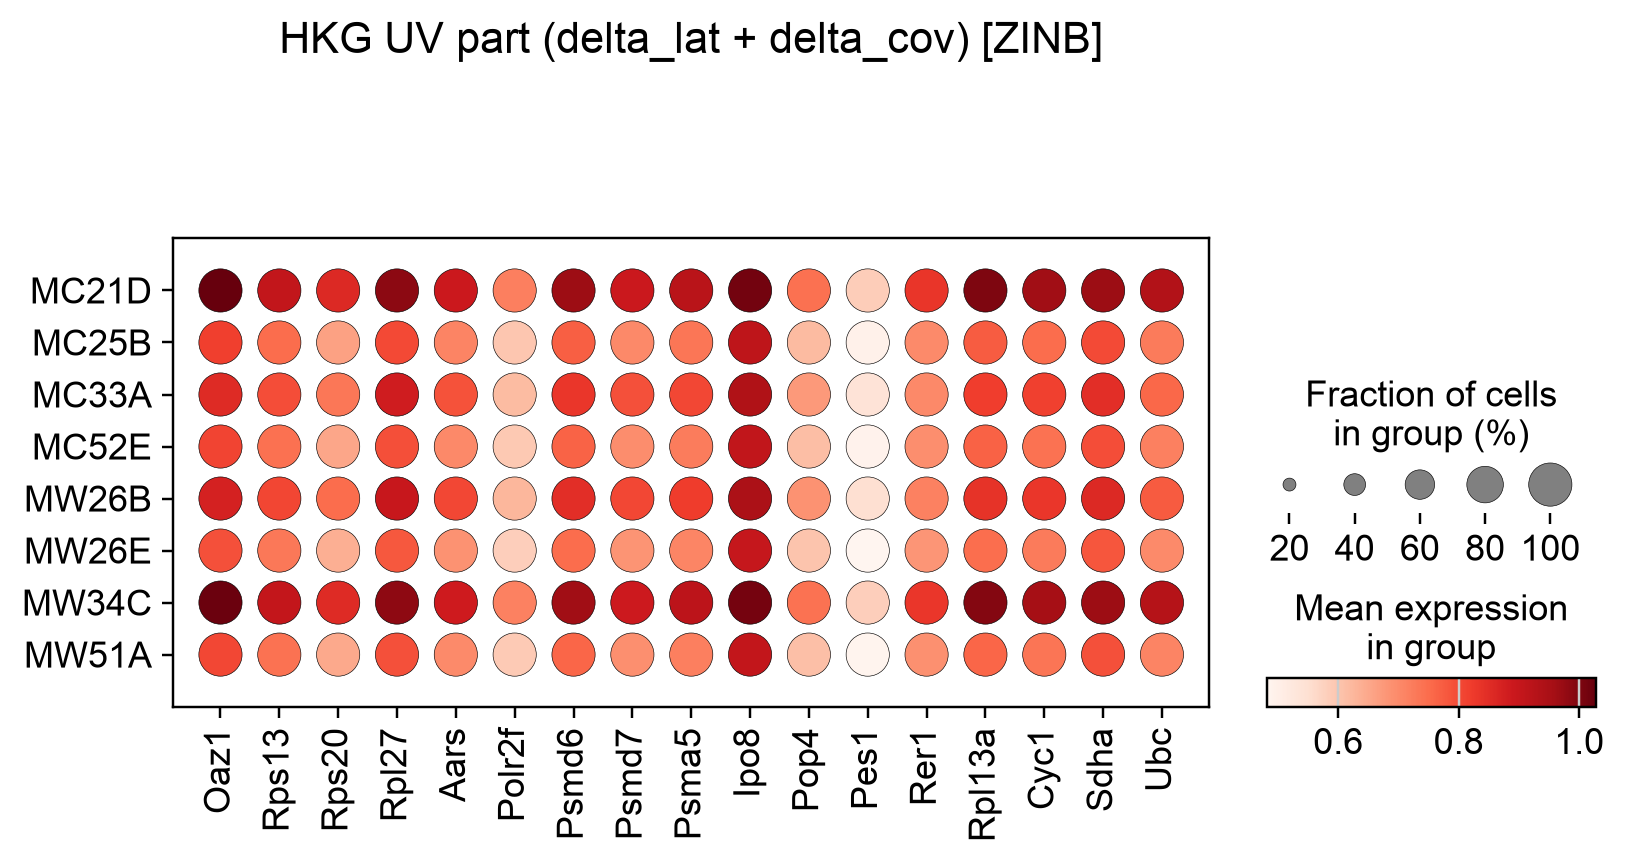

Saved: ZINB_hkg_raw_dotplot.png / ZINB_hkg_uv_removed_dotplot.png / ZINB_hkg_uv_part_dotplot.png


In [23]:
# ========== 9d. Scanpy dotplot：HKG raw / UV-removed / UV-part 三联图 [ZINB] ==========
import matplotlib.pyplot as plt

model_cpu.eval()
with torch.no_grad():
    c_dict_eval = {
        "group": torch.FloatTensor(np.eye(len(groups_unique))[group_idx]),
        "batch": torch.FloatTensor(np.eye(len(batches_unique))[batch_idx]),
        "n_genes_on": torch.FloatTensor(n_genes_on[:, None]),
    }
    out_eval = model_cpu(torch.FloatTensor(counts), c_dict_eval, torch.BoolTensor(neg_control_mask))
    delta_lat_eval = out_eval["delta_lat"].cpu().numpy()
    delta_cov_eval = out_eval["delta_cov"].cpu().numpy()

# 只用 HKG 基因
hkg_idx_full = [gene_names.index(g) for g in hkg_genes_used]
X_uv_part_full = np.zeros_like(counts)
X_uv_part_full[:, hkg_idx_full] = (
    delta_lat_eval[:, hkg_idx_full] + delta_cov_eval[:, hkg_idx_full]
)
adata_hvg.layers["X_uv_part"] = X_uv_part_full

print("counts shape:", counts.shape)
print("X_uv_removed (E[ZINB]) shape:", adata_hvg.layers["X_uv_removed"].shape)
print("X_bio shape:", adata_hvg.layers["X_bio"].shape)
print("X_uv_part shape:", adata_hvg.layers["X_uv_part"].shape)

sc.settings.set_figure_params(dpi=110)

# ---- 1. raw log1p ----
fig = sc.pl.dotplot(
    adata_hvg,
    var_names=hkg_genes_used,
    groupby="donor",
    use_raw=False,
    layer=None,
    standard_scale=None,
    cmap="Reds",
    show=False,
    title="HKG raw (raw log1p) [ZINB]",
    return_fig=True,
)
fig.savefig("ZINB_hkg_raw_dotplot.png", bbox_inches="tight")

# ---- 2. ZINB E[ZINB] ----
fig = sc.pl.dotplot(
    adata_hvg,
    var_names=hkg_genes_used,
    groupby="donor",
    use_raw=False,
    layer="X_uv_removed",
    standard_scale=None,
    cmap="Reds",
    show=False,
    title="HKG E[ZINB] = mu*(1-pi) [ZINB]",
    return_fig=True,
)
fig.savefig("ZINB_hkg_uv_removed_dotplot.png", bbox_inches="tight")

# ---- 3. UV part (delta_lat + delta_cov) ----
fig = sc.pl.dotplot(
    adata_hvg,
    var_names=hkg_genes_used,
    groupby="donor",
    use_raw=False,
    layer="X_uv_part",
    standard_scale=None,
    cmap="Reds",
    show=False,
    title="HKG UV part (delta_lat + delta_cov) [ZINB]",
    return_fig=True,
)
fig.savefig("ZINB_hkg_uv_part_dotplot.png", bbox_inches="tight")

plt.show()
print("Saved: ZINB_hkg_raw_dotplot.png / ZINB_hkg_uv_removed_dotplot.png / ZINB_hkg_uv_part_dotplot.png")
